<a href="https://colab.research.google.com/github/PrasannaMadiwar/LLM-from-Scratch-/blob/main/fine_tuning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import tiktoken
from torch.utils.data import Dataset,DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
class MultiHead(nn.Module):
  def __init__(self,d_in,d_out,context_length,drop_rate,n_heads,qkv_bias=True):

    super().__init__()
    assert(d_out % n_heads == 0)

    self.d_out = d_out
    self.n_heads = n_heads
    self.head_d = d_out // n_heads

    self.query = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.key = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.value = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(drop_rate)

    self.register_buffer('mask',torch.triu(torch.ones(context_length,context_length),diagonal=1))


  def forward(self,x):
    b,n_tokens,d_in = x.shape

    keys = self.key(x)
    values = self.value(x)
    queries = self.query(x)

    keys = keys.view(b,n_tokens,self.n_heads,self.head_d)
    values = values.view(b,n_tokens,self.n_heads,self.head_d)
    queries = queries.view(b,n_tokens,self.n_heads,self.head_d)

    keys = keys.transpose(1,2)
    values = values.transpose(1,2)
    queries = queries.transpose(1,2)

    attn_score = queries @ keys.transpose(2,3)
    mask_bool = self.mask.bool()[:n_tokens,:n_tokens]
    attn_score.masked_fill(mask_bool,-1e4)
    attn_weights = torch.softmax(attn_score / keys.shape[-1]**0.5,dim=-1)
    attn_weights = self.dropout(attn_weights)

    context_vec = (attn_weights @ values).transpose(1,2)
    context_vec = context_vec.contiguous().view(b,n_tokens,self.d_out)
    context_vec = self.proj(context_vec)

    return context_vec





In [3]:
class LayerNorm(nn.Module):

  def __init__(self,d_in):
    super().__init__()
    self.esp = 1e-5
    self.scale = nn.Parameter(torch.ones(d_in))
    self.shift = nn.Parameter(torch.zeros(d_in))
  def forward(self,x):
    mean = x.mean(dim=-1,keepdim=True)
    var = x.var(dim=-1,keepdim=True,unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.esp)

    return self.scale*norm_x+self.shift


In [4]:
class Gelu(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self,x):
    return 0.5 * x * (1 + torch.tanh(x * 0.7978845608 * (1 + 0.044715 * x * x)))

In [5]:
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()

    self.layers = nn.Sequential(
        nn.Linear(cfg['d_in'],cfg['d_in']*4),
        Gelu(),
        nn.Linear(cfg['d_in']*4,cfg['d_in'])
    )
  def forward(self,x):
    return self.layers(x)

In [6]:
class TransFormer(nn.Module):
  def __init__(self,cfg):
    super().__init__()

    self.norm1 = LayerNorm(cfg['d_in'])
    self.norm2 = LayerNorm(cfg['d_in'])
    self.M_attn = MultiHead(cfg['d_in'],cfg['d_out'],cfg['context_length'],cfg['drop_rate'],cfg['n_heads'],cfg['qkv_bias'])
    self.ff = FeedForward(cfg)
    self.drop_out = nn.Dropout(cfg['drop_rate'])

  def forward(self,x):
    shortcut = x
    x = self.norm1(x)
    x = self.M_attn(x)
    x = self.drop_out(x)
    x = shortcut + x

    shortcut = x
    x = self.norm2(x)
    x = self.ff(x)
    x =  self.drop_out(x)
    x = shortcut + x

    return x



In [7]:
class GPT_140M(nn.Module):
  def __init__(self,cfg):

    super().__init__()

    self.word_emb = nn.Embedding(cfg['vocab_size'],cfg['d_out'])
    self.pos_emb = nn.Embedding(cfg['context_length'],cfg['d_out'])
    self.dropout = nn.Dropout(cfg['drop_rate'])
    self.trf = nn.Sequential(
        *[TransFormer(cfg) for i in range(cfg['n_layers'])]
    )
    self.final_norm = LayerNorm(cfg['d_out'])
    self.output_head = nn.Linear(cfg['d_out'],cfg['vocab_size'],bias=False)

  def forward(self,ind_x):
    b,n_seq =  ind_x.shape
    tok_emb = self.word_emb(ind_x)
    pos_emb = self.pos_emb(torch.arange(n_seq,device=ind_x.device))
    x = tok_emb + pos_emb
    x = self.dropout(x)
    x = self.trf(x)
    x = self.final_norm(x)
    logits = self.output_head(x)
    return logits

In [8]:
cfg = {
    'vocab_size':50257,
    'd_out':768,
    'd_in':768,
    'context_length':1024,
    'drop_rate':0.1,
    'n_heads':12,
    'n_layers':12,
    'qkv_bias':True
}

In [9]:
model = GPT_140M(cfg)
tokenizer = tiktoken.get_encoding('gpt2')

In [10]:
model.to(device)

GPT_140M(
  (word_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (trf): Sequential(
    (0): TransFormer(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (M_attn): MultiHead(
        (query): Linear(in_features=768, out_features=768, bias=True)
        (key): Linear(in_features=768, out_features=768, bias=True)
        (value): Linear(in_features=768, out_features=768, bias=True)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): Gelu()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (drop_out): Dropout(p=0.1, inplace=False)
    )
    (1): TransFormer(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (M_attn): MultiHead(
        (query): Linear(in_fe

In [11]:
from os import replace
def generate_text(model,idx,max_new,context_size,tempreture,top_k):
  model.eval()
  idx = idx.to(device)
  for i in range(max_new):
    idx_cond = idx[:, -context_size:]
    logits = model(idx_cond)
    logits = logits[:,-1,:] / tempreture
    top_log,_ = torch.topk(logits,k=top_k)
    min_v = torch.min(top_log)
    logits[logits<min_v] = -float('inf')
    prob = torch.softmax(logits,dim=-1)
    id_new = torch.multinomial(prob,num_samples=1)
    idx = torch.cat((idx,id_new),dim=1)
  text = decode(idx,tokenizer=tokenizer)
  print(text.replace("\n", " "))




In [12]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    val_loss = calc_loss_loader(val_loader,model,device,num_batches=eval_iter)
    train_loss = calc_loss_loader(train_loader,model,device,num_batches=eval_iter)
    model.train()
  return train_loss,val_loss

In [13]:
'''def trainGpt(model,train_loader,val_loader,optimizer,device,num_epoch,eval_iter,eval_freq,start_context,tokenizer):
  train_losses,val_losses,seen_tokens = [],[],[]
  token_seen,global_step = 0,-1

  for i in range(num_epoch):
    model.train()
    for input_batch,target_batch in train_loader:
      optimizer.zero_grad()
      loss = calc_loss_batch(input_batch,target_batch,model,device)
      loss.backward()
      optimizer.step()
      train_losses.append(loss.item())
      token_seen += input_batch.numel()
      global_step += 1
      if global_step % eval_freq == 0:
        train_loss,val_loss = evaluate_model(model,train_loader,val_loader,device,eval_iter)
        print("Epoch:"+str(i)+" Training_Loss:"+str(train_loss)+" Validation_Loss:"+str(val_loss))
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        seen_tokens.append(token_seen)

    #generate_text(model=model,idx= encode(start_context,tokenizer=tokenizer),max_new=50,context_size=256,tempreture=1.21,top_k=5)
  return train_losses,val_losses,seen_tokens'''

'def trainGpt(model,train_loader,val_loader,optimizer,device,num_epoch,eval_iter,eval_freq,start_context,tokenizer):\n  train_losses,val_losses,seen_tokens = [],[],[]\n  token_seen,global_step = 0,-1\n\n  for i in range(num_epoch):\n    model.train()\n    for input_batch,target_batch in train_loader:\n      optimizer.zero_grad()\n      loss = calc_loss_batch(input_batch,target_batch,model,device)\n      loss.backward()\n      optimizer.step()\n      train_losses.append(loss.item())\n      token_seen += input_batch.numel()\n      global_step += 1\n      if global_step % eval_freq == 0:\n        train_loss,val_loss = evaluate_model(model,train_loader,val_loader,device,eval_iter)\n        print("Epoch:"+str(i)+" Training_Loss:"+str(train_loss)+" Validation_Loss:"+str(val_loss))\n        train_losses.append(train_loss)\n        val_losses.append(val_loss)\n        seen_tokens.append(token_seen)\n\n    #generate_text(model=model,idx= encode(start_context,tokenizer=tokenizer),max_new=50,cont

In [14]:

'''torch.manual_seed(123)
model.to(device)
optimizer= torch.optim.AdamW(model.parameters(),lr=0.0004,weight_decay=0.1)
num_epoch = 10'''

'torch.manual_seed(123)\nmodel.to(device)\noptimizer= torch.optim.AdamW(model.parameters(),lr=0.0004,weight_decay=0.1)\nnum_epoch = 10'

In [15]:
#train_loss,val_loss,n_token_seen = trainGpt(model,train_loader=train_loader,val_loader=val_loader,device=device,optimizer=optimizer,num_epoch=num_epoch,eval_iter=5,eval_freq=5,start_context="hello how are t",tokenizer=tokenizer)

In [16]:
'''train_loss,val_loss = evaluate_model(model,train_loader,val_loader,device,4)
print("train_loss: "+str(train_loss)+" val_loss: "+str(val_loss))'''


'train_loss,val_loss = evaluate_model(model,train_loader,val_loader,device,4)\nprint("train_loss: "+str(train_loss)+" val_loss: "+str(val_loss))'

In [17]:
'''start_context = "hey i am a boy i want to be an pilot"
generate_text(model=model,idx= encode(start_context,tokenizer=tokenizer),max_new=400,context_size=256,tempreture=1.21,top_k=10)'''

'start_context = "hey i am a boy i want to be an pilot"\ngenerate_text(model=model,idx= encode(start_context,tokenizer=tokenizer),max_new=400,context_size=256,tempreture=1.21,top_k=10)'

In [18]:
from transformers import GPT2LMHeadModel

gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
sd = gpt2.state_dict()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [19]:
for k in sd.keys():
  print(k)

transformer.wte.weight
transformer.wpe.weight
transformer.h.0.ln_1.weight
transformer.h.0.ln_1.bias
transformer.h.0.attn.c_attn.weight
transformer.h.0.attn.c_attn.bias
transformer.h.0.attn.c_proj.weight
transformer.h.0.attn.c_proj.bias
transformer.h.0.ln_2.weight
transformer.h.0.ln_2.bias
transformer.h.0.mlp.c_fc.weight
transformer.h.0.mlp.c_fc.bias
transformer.h.0.mlp.c_proj.weight
transformer.h.0.mlp.c_proj.bias
transformer.h.1.ln_1.weight
transformer.h.1.ln_1.bias
transformer.h.1.attn.c_attn.weight
transformer.h.1.attn.c_attn.bias
transformer.h.1.attn.c_proj.weight
transformer.h.1.attn.c_proj.bias
transformer.h.1.ln_2.weight
transformer.h.1.ln_2.bias
transformer.h.1.mlp.c_fc.weight
transformer.h.1.mlp.c_fc.bias
transformer.h.1.mlp.c_proj.weight
transformer.h.1.mlp.c_proj.bias
transformer.h.2.ln_1.weight
transformer.h.2.ln_1.bias
transformer.h.2.attn.c_attn.weight
transformer.h.2.attn.c_attn.bias
transformer.h.2.attn.c_proj.weight
transformer.h.2.attn.c_proj.bias
transformer.h.2.ln_2

In [20]:
def copy_weights(model):

  model.word_emb.weight.data.copy_(sd["transformer.wte.weight"])
  model.pos_emb.weight.data.copy_(sd["transformer.wpe.weight"])
  model.final_norm.scale.data.copy_(sd["transformer.ln_f.weight"])
  model.final_norm.shift.data.copy_(sd["transformer.ln_f.bias"])
  model.output_head.weight.data.copy_(sd["transformer.wte.weight"])


  for i in range(12):
      block = model.trf[i]
      prefix = f"transformer.h.{i}."

      block.norm1.scale.data.copy_(sd[prefix + "ln_1.weight"])
      block.norm1.shift.data.copy_(sd[prefix + "ln_1.bias"])

      qkv_w = sd[prefix + "attn.c_attn.weight"]
      qkv_b = sd[prefix + "attn.c_attn.bias"]

      qw, kw, vw = qkv_w.split(768, dim=1)
      qb, kb, vb = qkv_b.split(768)

      block.M_attn.query.weight.data.copy_(qw.T)
      block.M_attn.query.bias.data.copy_(qb.T)
      block.M_attn.key.weight.data.copy_(kw.T)
      block.M_attn.key.bias.data.copy_(kb.T)
      block.M_attn.value.weight.data.copy_(vw.T)
      block.M_attn.value.bias.data.copy_(vb.T)
      block.M_attn.proj.weight.data.copy_(sd[prefix + "attn.c_proj.weight"].T)
      block.M_attn.proj.bias.data.copy_(sd[prefix + "attn.c_proj.bias"])

      block.ff.layers[0].weight.data.copy_(sd[prefix + "mlp.c_fc.weight"].T)
      block.ff.layers[0].bias.data.copy_(sd[prefix + "mlp.c_fc.bias"].T)
      block.ff.layers[2].weight.data.copy_(sd[prefix + "mlp.c_proj.weight"].T)
      block.ff.layers[2].bias.data.copy_(sd[prefix + "mlp.c_proj.bias"].T)

      block.norm2.scale.data.copy_(sd[prefix + "ln_2.weight"])
      block.norm2.shift.data.copy_(sd[prefix + "ln_2.bias"])




In [21]:
copy_weights(model=model)
torch.manual_seed(123)
#generate_text(model=model,idx= encode("all girls are idiots",tokenizer=tokenizer),max_new=20,context_size=cfg['context_length'],tempreture=1.5,top_k=50)

/tmp/ipython-input-3345346951.py:24: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4416.)
  block.M_attn.query.bias.data.copy_(qb.T)


In [22]:
model.to(device)

GPT_140M(
  (word_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (trf): Sequential(
    (0): TransFormer(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (M_attn): MultiHead(
        (query): Linear(in_features=768, out_features=768, bias=True)
        (key): Linear(in_features=768, out_features=768, bias=True)
        (value): Linear(in_features=768, out_features=768, bias=True)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): Gelu()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (drop_out): Dropout(p=0.1, inplace=False)
    )
    (1): TransFormer(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (M_attn): MultiHead(
        (query): Linear(in_fe

In [23]:
import pandas as pd

In [24]:
import urllib.request
import ssl
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return


    ssl_context = ssl._create_unverified_context()


    with urllib.request.urlopen(url, context=ssl_context) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())


    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [25]:
df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])

In [26]:
num_spam = df[df["Label"] == "spam"].shape[0]
ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [27]:
balanced_df['Label'].value_counts()

,count
Label,
0,747
1,747


In [28]:
df = balanced_df.sample(frac=1, random_state=123).reset_index(drop=True)
train_end = int(len(balanced_df) * 0.7)
validation_end = train_end + int(len(balanced_df) * 0.2)

train_df = balanced_df[:train_end]
validation_df = balanced_df[train_end:validation_end]
test_df = balanced_df[validation_end:]

In [29]:
train_df['Label'].value_counts()

,count
Label,
0,747
1,298


In [30]:
class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = csv_file


        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = len(max(self.encoded_texts,key=len))
        else:
            self.max_length = max_length


            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]


        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

In [31]:
train_data = SpamDataset(train_df, tokenizer)
val_data = SpamDataset(validation_df, tokenizer)
test_data = SpamDataset(test_df, tokenizer)

In [32]:
torch.manual_seed(123)
train_loader = DataLoader(dataset=train_data,batch_size=8,shuffle=True,num_workers=0)
val_loader = DataLoader(dataset=val_data,batch_size=8,shuffle=False,num_workers=0)
test_loader = DataLoader(dataset=test_data,batch_size=8,shuffle=False,num_workers=0)

In [41]:
torch.manual_seed(123)

model.output_head = torch.nn.Linear(in_features=cfg['d_in'], out_features=2)
for param in model.trf[-1].parameters():
  param.requires_grad = True
for param in model.final_norm.parameters():
  param.requires_grad = True
model.to(device)

GPT_140M(
  (word_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (trf): Sequential(
    (0): TransFormer(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (M_attn): MultiHead(
        (query): Linear(in_features=768, out_features=768, bias=True)
        (key): Linear(in_features=768, out_features=768, bias=True)
        (value): Linear(in_features=768, out_features=768, bias=True)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): Gelu()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (drop_out): Dropout(p=0.1, inplace=False)
    )
    (1): TransFormer(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (M_attn): MultiHead(
        (query): Linear(in_fe

In [42]:
def calc_loss_batch1(input_batch,target_batch,model,device):
  input_batch,target_batch = input_batch.to(device),target_batch.to(device)
  logits = model(input_batch)[:,-1,:]
  loss = torch.nn.functional.cross_entropy(logits,target_batch)
  return loss

In [43]:
def calc_loss_loader1(data_loader,model,device,num_batches=None):
  total_loss = 0
  if len(data_loader)<0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches,len(data_loader))

  for i ,(input_batch,target_batch) in enumerate(data_loader):
    if i<num_batches:
      loss = calc_loss_batch1(input_batch,target_batch,model,device)
      total_loss += loss
    else:
        break

  return total_loss / num_batches

In [44]:
def evaluate1(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    val_loss = calc_loss_loader1(val_loader,model,device,num_batches=eval_iter)
    train_loss = calc_loss_loader1(train_loader,model,device,num_batches=eval_iter)
    model.train()

  return train_loss,val_loss

In [62]:
def fine_Gpt(model,train_loader,val_loader,optimizer,device,num_epoch,eval_iter,eval_freq,tokenizer):
  train_losses,val_losses = [],[]
  token_seen,global_step = 0,-1

  for i in range(num_epoch):
    model.train()
    for input_batch,target_batch in train_loader:
      optimizer.zero_grad()
      loss = calc_loss_batch1(input_batch,target_batch,model,device)
      loss.backward()
      optimizer.step()
      train_losses.append(loss.item())
      token_seen += input_batch.shape[0]
      global_step += 1
      if global_step % eval_freq == 0:
        train_loss,val_loss = evaluate1(model,train_loader,val_loader,device,eval_iter)
        print("Epoch:"+str(i)+" Training_Loss:"+str(train_loss)+" Validation_Loss:"+str(val_loss))
        train_losses.append(train_loss)
        val_losses.append(val_loss)



  return train_losses,val_losses,token_seen

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.AdamW(model.parameters(),lr=0.0004,weight_decay=0.1)
num_epoch = 10
train_loss,val_loss,n_token_seen = fine_Gpt(model,train_loader=train_loader,val_loader=val_loader,optimizer=optimizer,device=device,num_epoch=num_epoch,eval_iter=5,eval_freq=5,tokenizer=tokenizer)

Epoch:0 Training_Loss:tensor(1.9073e-07, device='cuda:0') Validation_Loss:tensor(0.0245, device='cuda:0')
Epoch:0 Training_Loss:tensor(0., device='cuda:0') Validation_Loss:tensor(8.9407e-09, device='cuda:0')
Epoch:0 Training_Loss:tensor(0., device='cuda:0') Validation_Loss:tensor(0., device='cuda:0')
Epoch:0 Training_Loss:tensor(0., device='cuda:0') Validation_Loss:tensor(0., device='cuda:0')
Epoch:0 Training_Loss:tensor(0., device='cuda:0') Validation_Loss:tensor(0., device='cuda:0')
Epoch:0 Training_Loss:tensor(0., device='cuda:0') Validation_Loss:tensor(0., device='cuda:0')
Epoch:0 Training_Loss:tensor(0., device='cuda:0') Validation_Loss:tensor(0., device='cuda:0')
Epoch:0 Training_Loss:tensor(0., device='cuda:0') Validation_Loss:tensor(0., device='cuda:0')
Epoch:0 Training_Loss:tensor(0., device='cuda:0') Validation_Loss:tensor(0., device='cuda:0')
Epoch:0 Training_Loss:tensor(0., device='cuda:0') Validation_Loss:tensor(0., device='cuda:0')
Epoch:0 Training_Loss:tensor(0., device=

KeyboardInterrupt: 

In [64]:
def classify_review(text, model, tokenizer, device, max_length=120, pad_token_id=50256):
    model.eval()


    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]

    input_ids = input_ids[:min(max_length, supported_context_length)]

    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)


    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    predicted_label = torch.argmax(logits, dim=-1).item()


    return "spam" if predicted_label == 1 else "not spam"

In [65]:
classify_review("Hii you have the 100000 amount please share the otp",model=model,tokenizer=tokenizer,device=device)

'spam'

In [66]:
import matplotlib.pyplot as plt

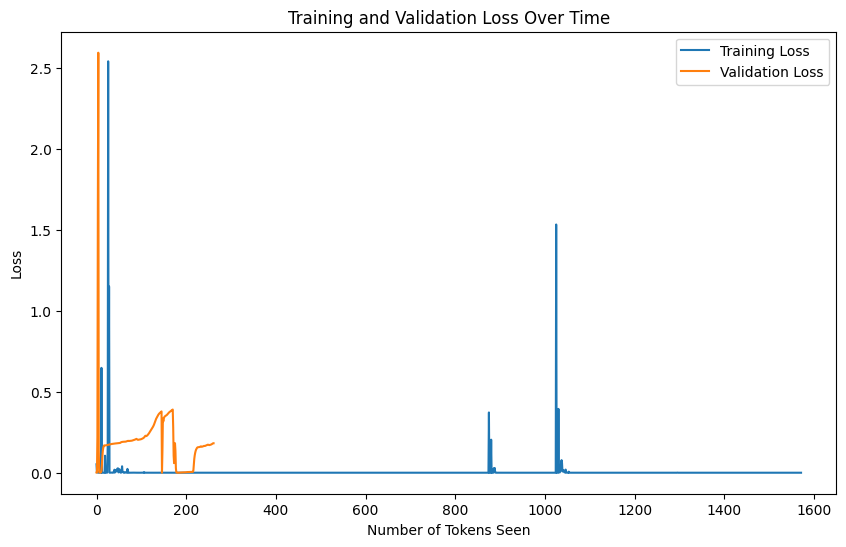

In [68]:
train_loss = [x.cpu().item() if torch.is_tensor(x) else x for x in train_loss]
val_loss   = [x.cpu().item() if torch.is_tensor(x) else x for x in val_loss]


plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Number of Tokens Seen')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.show()